In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import datetime as dt


In [2]:
# drive.mount('/content/drive')
data_file = pd.read_excel("Bonneville_Salt_Flat_08_05_2025_logs.xlsx")
car_park = pd.read_excel("08_04_2025_logs.xlsx")

# data_file = pd.read_excel("")




In [3]:
solar_panel_timestamp = data_file['Solar Panel Timestamp']# Clean data
solar_panel_power = data_file['Power Output Calculated']# Clean data
solar_panel_voltage = data_file['Solar Panel Voltage']# Clean data
solar_panel_current = data_file['Solar Panel Current']# Clean data


telescope_timestamp = data_file['Telescope Timestamp Start']
telescope_timestamp_end = data_file['Telescope Timestamp End']
#remove NaT values form time stamp
telescope_timestamp = telescope_timestamp[telescope_timestamp.notna()]
gamma = data_file['Gamma (deg)']
gamma = gamma[gamma.notna()]
cos_gamma = data_file['cos(Gamma)']
altitude = data_file['Altitude (deg)']

carpark_solar_timestamp = car_park['Solar Panel Timestamp']# Clean data
carpark_solar_power = car_park['Power Output Calculated']# Clean data
carpark_telescope_timestamp = car_park['Telescope Timestamp Start'][0:35]
carpark_telescope_timestamp_end = car_park['Telescope Timestamp End'][0:35]
carpark_gamma = car_park['Gamma (deg)'][0:35]

[datetime.datetime(2025, 8, 5, 12, 29, 43), datetime.datetime(2025, 8, 5, 12, 29, 48), datetime.datetime(2025, 8, 5, 12, 29, 53), datetime.datetime(2025, 8, 5, 12, 29, 58), datetime.datetime(2025, 8, 5, 12, 30, 3), datetime.datetime(2025, 8, 5, 12, 30, 8), datetime.datetime(2025, 8, 5, 12, 30, 13), datetime.datetime(2025, 8, 5, 12, 30, 18), datetime.datetime(2025, 8, 5, 12, 30, 23), datetime.datetime(2025, 8, 5, 12, 30, 28), datetime.datetime(2025, 8, 5, 12, 30, 33), datetime.datetime(2025, 8, 5, 12, 30, 38), datetime.datetime(2025, 8, 5, 12, 30, 43), datetime.datetime(2025, 8, 5, 12, 30, 48), datetime.datetime(2025, 8, 5, 12, 30, 53), datetime.datetime(2025, 8, 5, 12, 30, 58), datetime.datetime(2025, 8, 5, 12, 31, 3), datetime.datetime(2025, 8, 5, 12, 31, 8), datetime.datetime(2025, 8, 5, 12, 31, 13), datetime.datetime(2025, 8, 5, 12, 31, 18), datetime.datetime(2025, 8, 5, 12, 31, 23), datetime.datetime(2025, 8, 5, 12, 31, 28), datetime.datetime(2025, 8, 5, 12, 31, 33), datetime.datet

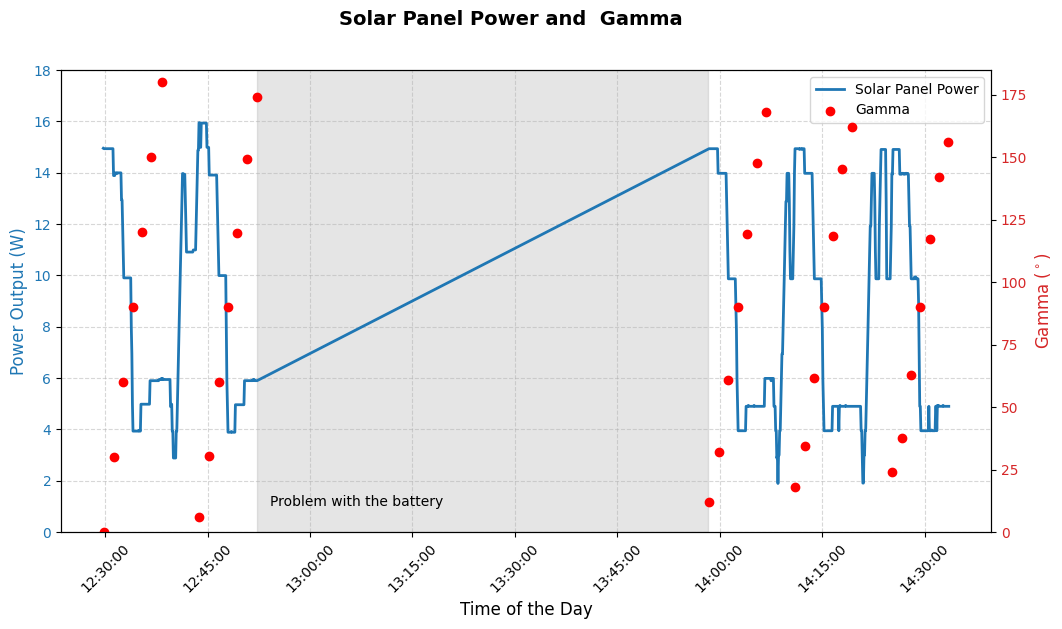

In [69]:
base_date = dt.datetime(2025, 8, 5)
solar_panel_datetime = [dt.datetime.combine(base_date.date(), t) for t in solar_panel_timestamp]
telescope_datetime = [dt.datetime.combine(base_date.date(), t) for t in telescope_timestamp]

print(solar_panel_datetime)
print(telescope_datetime)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Solar Panel Power

ax1.plot(solar_panel_datetime, solar_panel_power, color='tab:blue', label='Solar Panel Power', linewidth=2)
ax1.set_ylabel("Power Output (W)", color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Time of the Day", fontsize=12)
ax1.set_ylim(0, 18)
#Fill the gap between 12:52 to 12:58
ax1.axvspan(dt.datetime(2025, 8, 5,12,52,10), dt.datetime(2025, 8, 5,13,58,20), color='gray', alpha=0.2)
#Write the text in that fill area
ax1.text(dt.datetime(2025, 8, 5,12,54,10),1,'Problem with the battery')

# Format the x-axis as time (HH:MM)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

# Create second axis for Gamma
ax2 = ax1.twinx()
ax2.scatter(telescope_datetime, gamma, color='red', label='Gamma')
ax2.set_ylabel(r"Gamma ($^\circ$)", color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 185)

# Add grid, title, and legends
ax1.grid(True, linestyle='--', alpha=0.5)
fig.suptitle("Solar Panel Power and  Gamma", fontsize=14, weight='bold')
# fig.tight_layout(rect=[0, 0, 1, 0.95])

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
plt.show()

In [70]:
from scipy.optimize import curve_fit


# Create dataframes and remove NaT / NaNs
solar_df = pd.DataFrame({
    'solar_start_time': solar_panel_timestamp,
    'power': solar_panel_power
}).dropna()

telescope_df = pd.DataFrame({
    'scope_start_time': telescope_timestamp,
    'scope_end_time': telescope_timestamp_end,
    'gamma': gamma,
    'altitude': altitude
}).dropna()
#Remove nan from solar_df

# Create dataframes and remove NaT / NaNs
carpark_solar_df = pd.DataFrame({
    'solar_start_time': carpark_solar_timestamp,
    'power': carpark_solar_power
}).dropna()

carpark_telescope_df = pd.DataFrame({
    'scope_start_time': carpark_telescope_timestamp,
    'scope_end_time': carpark_telescope_timestamp_end,
    'gamma': carpark_gamma,
    # 'altitude': carpark_altitude
}).dropna()
#Remove nan from solar_df

base_date = dt.datetime(2025, 8, 5)

solar_panel_datetime = [dt.datetime.combine(base_date.date(), t) for t in solar_df['solar_start_time']]
telescope_datetime = [dt.datetime.combine(base_date.date(), t) for t in telescope_df['scope_start_time']]
# telescope_datetime = pd.to_datetime(telescope_datetime)
# solar_panel_datetime = pd.to_datetime(solar_panel_datetime)

carpark_solar_panel_datetime = [base_date + t for t in carpark_solar_df['solar_start_time']]
carpark_telescope_datetime = [base_date + t for t in carpark_telescope_df['scope_start_time']]
# carpark_telescope_datetime = pd.to_datetime(carpark_telescope_datetime)
# carpark_solar_panel_datetime = pd.to_datetime(carpark_solar_panel_datetime)
print('carpark_telescope_datetime:', carpark_telescope_datetime)
print('telescope_datetime:',telescope_datetime)





carpark_telescope_datetime: [datetime.datetime(2025, 8, 5, 12, 10, 57), datetime.datetime(2025, 8, 5, 12, 12, 28), datetime.datetime(2025, 8, 5, 12, 13, 52), datetime.datetime(2025, 8, 5, 12, 15, 13), datetime.datetime(2025, 8, 5, 12, 16, 34), datetime.datetime(2025, 8, 5, 12, 17, 58), datetime.datetime(2025, 8, 5, 12, 19, 28), datetime.datetime(2025, 8, 5, 12, 24, 53), datetime.datetime(2025, 8, 5, 12, 26, 21), datetime.datetime(2025, 8, 5, 12, 27, 45), datetime.datetime(2025, 8, 5, 12, 29, 6), datetime.datetime(2025, 8, 5, 12, 30, 28), datetime.datetime(2025, 8, 5, 12, 31, 52), datetime.datetime(2025, 8, 5, 12, 33, 20), datetime.datetime(2025, 8, 5, 12, 39, 29), datetime.datetime(2025, 8, 5, 12, 40, 55), datetime.datetime(2025, 8, 5, 12, 42, 18), datetime.datetime(2025, 8, 5, 12, 43, 40), datetime.datetime(2025, 8, 5, 12, 45, 2), datetime.datetime(2025, 8, 5, 12, 46, 25), datetime.datetime(2025, 8, 5, 12, 47, 51), datetime.datetime(2025, 8, 5, 12, 52, 4), datetime.datetime(2025, 8, 5

In [71]:
mean_power = []
error_bars = []
for j in telescope_datetime:
    powers_in_range = []
    for i, power in zip(solar_panel_datetime, solar_df['power']):
        if (i > j) and (i <  j + pd.Timedelta(60,'s')):
            powers_in_range.append(power)
    mean_power.append(np.mean(powers_in_range))
    error_bars.append(np.std(powers_in_range))



carpark_mean_power = []
carpark_error_bars = []
for j in carpark_telescope_datetime:
    powers_in_range = []
    for i, power in zip(carpark_solar_panel_datetime, carpark_solar_df['power']):
        if (i > j) and (i <  j + pd.Timedelta(seconds=60)):
            powers_in_range.append(power)
    carpark_mean_power.append(np.mean(powers_in_range))
    carpark_error_bars.append(np.std(powers_in_range))

In [72]:
def piecewise_linear(x, P_dir, P_dif):
    # x0 is the breakpoint
    return np.piecewise(x, [x < 0, x >= 0],
                        [lambda x_val: P_dif,
                          lambda x_val: P_dir * x_val + P_dif])


P_max=np.amax(mean_power)
initial_guess = [0.5*P_max,0.5*P_max]
# Fit the curve
x_data=np.cos(gamma/180*3.1415).values
y_data=np.array(mean_power)

sort_idx = np.argsort(x_data)
x_sorted = x_data[sort_idx]
y_sorted = y_data[sort_idx]


x_data_carpark = np.cos(carpark_gamma/180*3.1415).values
y_data_carpark = np.array(carpark_mean_power)

sort_idx_carpark = np.argsort(x_data_carpark)
x_sorted_carpark = x_data_carpark[sort_idx_carpark]
y_sorted_carpark = y_data_carpark[sort_idx_carpark]


#find the index of nan y_sorted
# print(x_sorted)
# print(y_sorted)
popt, pcov = curve_fit(piecewise_linear, x_sorted, y_sorted, p0=initial_guess)

popt_carpark, pcov_carpark = curve_fit(piecewise_linear, x_sorted_carpark, y_sorted_carpark, p0=initial_guess)



P_dir=popt[0]
P_dif=popt[1]

P_dir_carpark=popt_carpark[0]
P_dif_carpark=popt_carpark[1]


y_fit=piecewise_linear(x_sorted,P_dir,P_dif)

y_fit_carpark=piecewise_linear(x_sorted_carpark,P_dir_carpark,P_dif_carpark)




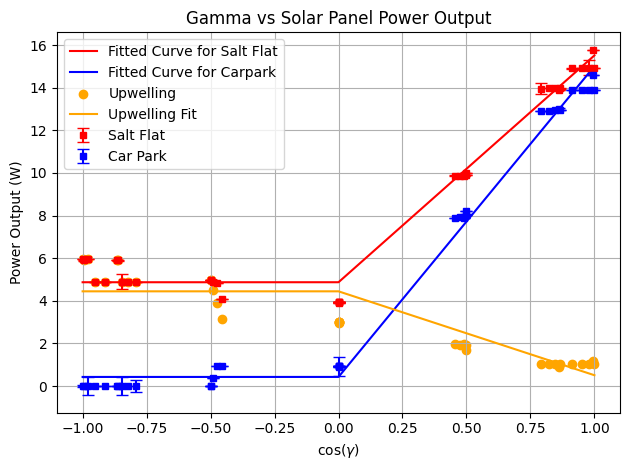

[5.94375    5.896      5.97625    4.896      4.896      5.895
 5.89966667 4.896      4.899      4.899      4.978      4.958
 4.51108333 3.87866667 3.16708333 3.0025     3.006      3.013
 2.96441667 3.0225     1.97833333 1.91825    1.958      1.94475
 1.70458333 1.039      1.054      1.02066667 0.91016667 1.039
 1.015      1.04089394 1.02236364 1.19375    1.03916667]


TypeError: type numpy.ndarray doesn't define __round__ method

In [73]:
plt.errorbar(x_sorted, y_sorted, yerr=error_bars, fmt='s', color='red', capsize=4, markersize = 5,label = 'Salt Flat')
plt.errorbar(x_sorted_carpark, y_sorted_carpark, yerr=carpark_error_bars, fmt='s', color='blue', capsize=4, markersize = 5,label = "Car Park")

upwelling_data = y_sorted - y_sorted_carpark


plt.plot(x_sorted, y_fit,color='red',label = "Fitted Curve for Salt Flat")
plt.plot(x_sorted_carpark, y_fit_carpark,label= "Fitted Curve for Carpark",color='blue')
plt.scatter(x_sorted, upwelling_data, color='orange',label = "Upwelling")
plt.plot(x_sorted,y_fit-y_fit_carpark,color='orange',label = "Upwelling Fit")
# plt.text(-0.95,14,r"$\mathrm{P}_{\mathrm{dir}}$ (W): " +f"{P_dir:.3f}")
# plt.text(-0.95,13,r"$\mathrm{P}_{\mathrm{dif}}$ (W): " +f"{P_dif:.3f}")


plt.xlabel(r'cos($\gamma$)')
plt.ylabel('Power Output (W)')
plt.title('Gamma vs Solar Panel Power Output')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()
print(upwelling_data)
print("Upwelling",round(upwelling_data,2))
print("Carpark",)



In [74]:
# next step Plot the average power output for each gamma
print(np.column_stack((np.cos(np.radians(merged['gamma'][0:6])),merged['power'][:6])))

plt.scatter(np.cos(np.radians(merged['gamma'][0:6])),merged['power'][:6])
# plt.scatter(np.cos(np.radians(merged['gamma'][6:12])),merged['power'][6:12])
# plt.scatter(np.cos(np.radians(merged['gamma'][12:18])),merged['power'][12:18])

NameError: name 'merged' is not defined

In [75]:
## Piecewise plot

from scipy.optimize import curve_fit

def piecewise_linear(x, P_dir, P_dif):
    # x0 is the breakpoint
    return np.piecewise(x, [x < 0, x >= 0],
                        [lambda x_val: P_dif*(x_val),
                          lambda x_val: P_dir * x_val + P_dif])

# Sample data

# Initial guess for parameters (P_dir,P_dif)
P_max=np.amax(merged['power'][0:6])
initial_guess = [0*P_max,0.5*P_max]
# Fit the curve
x_data=np.cos(np.radians(merged['gamma'][0:6])).values
y_data=merged['power'][0:6].values
popt, pcov = curve_fit(piecewise_linear, x_data, y_data, p0=initial_guess)
P_dir=popt[0]
P_dif=popt[1]
y_fit=piecewise_linear(x_data,P_dir,P_dif)
#set y fit to 0
y_fit = [a if a > 0 else 0 for a in y_fit]

print("Optimized parameters:", popt)

NameError: name 'merged' is not defined

In [76]:
### Plot using above values
plt.scatter(np.cos(np.radians(merged['gamma'][6:12])), merged['power'][6:12],label = "Power Output Data")
plt.plot(x_data, y_fit,label= "Fitted Curve")

plt.text(-0.95,14,r"$\mathrm{P}_{\mathrm{dir}}$ (W): " +f"{P_dir:.3f}")
plt.text(-0.95,13,r"$\mathrm{P}_{\mathrm{dif}}$ (W): " +f"{P_dif:.3f}")


plt.xlabel(r'cos($\gamma$)')
plt.ylabel('Power Output (W)')
plt.title('Gamma vs Solar Panel Power Output')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()



NameError: name 'merged' is not defined

In [77]:


# Create dataframes and remove NaT / NaNs
solar_df = pd.DataFrame({
    'solar_start_time': pd.to_timedelta(solar_panel_timestamp),
    'power': solar_panel_power
}).dropna()

telescope_df = pd.DataFrame({
    'scope_start_time': pd.to_timedelta(telescope_timestamp),
    'scope_end_time': pd.to_timedelta(telescope_timestamp_end),
    'gamma': gamma,
    'altitude': altitude
}).dropna()

# Add base datetime
base_date = pd.Timestamp('2025-08-04')
solar_df['datetime'] = base_date + solar_df['solar_start_time']
telescope_df['datetime'] = base_date + telescope_df['scope_start_time']


# mean_power = []
# for j in telescope_df['scope_start_time']:
#   powers_in_range = []
#   for i in solar_df['solar_start_time']:
#     if pd.to_datetime(i) > pd.to_datetime(j) & pd.to_datetime(i) < pd.to_datetime(j)+60:
#       powers_in_range.append(i)
#   mean_power.append(np.mean(powers_in_range))
# for i in mean_power:
#   print(i)


mean_power = []
for j in telescope_df['datetime']:
    powers_in_range = []
    for i, power in zip(solar_df['datetime'], solar_df['power']):
        if (i > j) and (i < j + pd.Timedelta(seconds=60)):
            powers_in_range.append(power)
    mean_power.append(np.mean(powers_in_range))
print(len(mean_power))
print(mean_power)
plt.scatter(np.arange(35),mean_power)
plt.show()




TypeError: Invalid type for timedelta scalar: <class 'datetime.time'>